In [1]:
import kagglehub

try:
    dataset_path = kagglehub.dataset_download("jangedoo/utkface-new")
    print("Path to dataset files:", dataset_path)
except Exception as e:
    print(e)

/Users/kimilehmann/Library/Mobile Documents/com~apple~CloudDocs/Documents/HHN/SEB6/Vertiefung/Datenanalyse in Unternehmen/Projekt/AgeLens/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/kimilehmann/.cache/kagglehub/datasets/jangedoo/utkface-new/versions/1


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageStat
import random
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, BatchNormalization, Dropout, RandomFlip, RandomRotation, RandomZoom
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical

In [ ]:
IMG_SIZE    = (48, 48)
BLUR_THRESH = 30.0
BRIGHT_MIN  = 30.0
BRIGHT_MAX  = 220.0

def is_blurry(img_gray, threshold=BLUR_THRESH):
    arr = np.array(img_gray, dtype=np.float32)
    laplacian = (
        arr[:-2,1:-1] + arr[2:,1:-1] + arr[1:-1,:-2] + arr[1:-1,2:]
        - 4 * arr[1:-1,1:-1]
    )
    return laplacian.var() < threshold

def is_bad_brightness(img_gray):
    mean = ImageStat.Stat(img_gray).mean[0]
    return mean < BRIGHT_MIN or mean > BRIGHT_MAX

def load_data(dataset_path):
    img_dir = os.path.join(dataset_path, "UTKFace")
    if not os.path.exists(img_dir):
        img_dir = dataset_path

    X, y = [], []
    skipped = {"age_range": 0, "blurry": 0, "brightness": 0, "bad_filename": 0}

    files = [f for f in os.listdir(img_dir) if f.endswith(".jpg")]

    for filename in files:
        parts = filename.split("_")
        if len(parts) < 4:
            skipped["bad_filename"] += 1
            continue
        try:
            gender = int(parts[1])
        except ValueError:
            skipped["bad_filename"] += 1
            continue

        img_path = os.path.join(img_dir, filename)
        img_gray = Image.open(img_path).convert("L").resize(IMG_SIZE)

        if is_blurry(img_gray):
            skipped["blurry"] += 1
            continue
        if is_bad_brightness(img_gray):
            skipped["brightness"] += 1
            continue

        X.append(np.array(img_gray, dtype=np.float32))
        y.append(gender)

    print(f"Geladen     : {len(X)} Bilder")
    print(f"Übersprungen: {skipped}")

    X = np.array(X).reshape(-1, IMG_SIZE[0], IMG_SIZE[1], 1)
    y = np.array(y, dtype=np.float32)
    return X, y

X, y = load_data(dataset_path)

Geladen     : 23695 Bilder
Übersprungen: {'age_range': 0, 'blurry': 5, 'brightness': 5, 'bad_filename': 3}


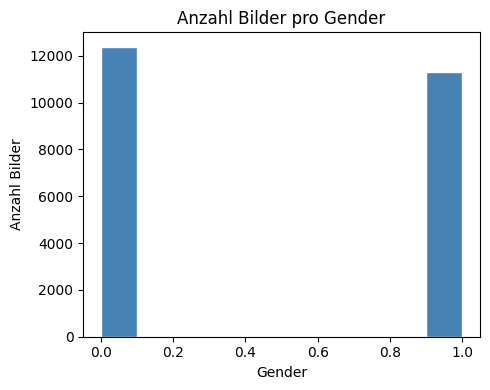

Gender: min=0, max=1


In [ ]:
plt.figure(figsize=(5, 4))
plt.hist(y, color="steelblue", edgecolor="white")
plt.xlabel("Gender")
plt.ylabel("Anzahl Bilder")
plt.title("Anzahl Bilder pro Gender")
plt.tight_layout()
plt.show()

print(f"Gender: min={y.min():.0f}, max={y.max():.0f}")

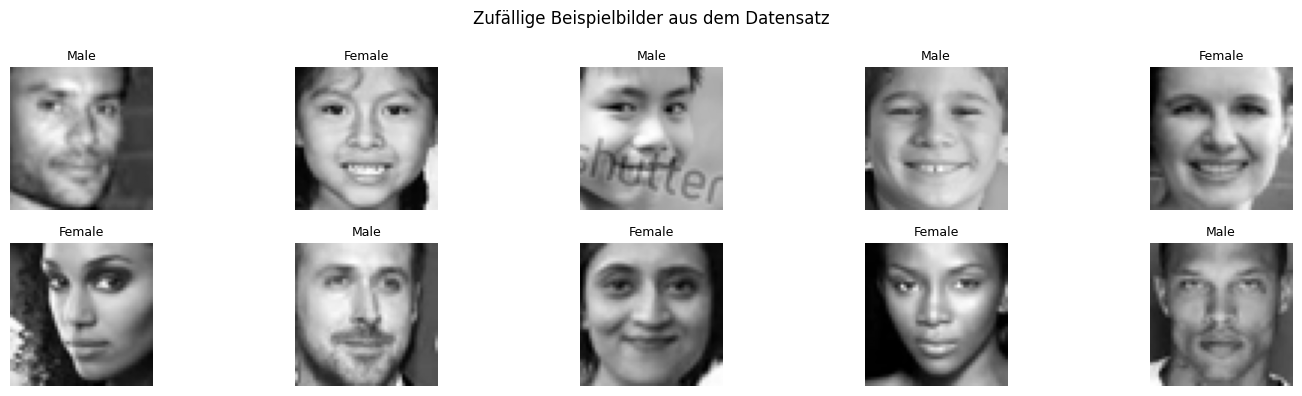

In [ ]:
plt.figure(figsize=(15, 4))
indices = random.sample(range(len(X)), 10)
gender_labels = {0: "Male", 1: "Female"} 
for i, idx in enumerate(indices):
    plt.subplot(2, 5, i+1)
    plt.imshow(X[idx].reshape(IMG_SIZE), cmap="gray")
    plt.title("Male" if y[idx] == 0 else "Female", fontsize=9)
    plt.axis("off")
plt.suptitle("Zufällige Beispielbilder aus dem Datensatz")
plt.tight_layout()
plt.show()

In [7]:
num_classes = int(y.max()) + 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train /= 255.0
X_test  /= 255.0

y_train = to_categorical(y_train)
y_test  = to_categorical(y_test)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}  num_classes: {num_classes}")
print(f"X_test : {X_test.shape}   y_test : {y_test.shape}   num_classes: {num_classes}")

X_train: (18956, 48, 48, 1)  y_train: (18956, 2)  num_classes: 2
X_test : (4739, 48, 48, 1)   y_test : (4739, 2)   num_classes: 2


In [ ]:
model = Sequential([
    RandomFlip("horizontal", input_shape=(48, 48, 1)),
    RandomRotation(0.1),
    RandomZoom(0.1),

    Conv2D(32, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dropout(0.4),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax", name="race")
])

model.compile(
    optimizer="adam", 
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 48, 48, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ race (Dense)                    │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,778 (2.61 MB)

 Trainable params: 683,330 (2.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        "../models/best_gender_predict_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_accuracy",
        factor=0.5,
        patience=5,
        mode="max",
        verbose=1
    )
]

history = model.fit(
    X_train, 
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/200
474/474 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6608 - loss: 0.8775
Epoch 1: val_accuracy improved from None to 0.78507, saving model to ../models/best_gender_predict_model.keras

Epoch 1: finished saving model to ../models/best_gender_predict_model.keras
474/474 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.7092 - loss: 0.6167 - val_accuracy: 0.7851 - val_loss: 0.4575 - learning_rate: 0.0010
Epoch 2/200
472/474 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7846 - loss: 0.4658
Epoch 2: val_accuracy did not improve from 0.78507
474/474 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.7882 - loss: 0.4563 - val_accuracy: 0.8107 - val_loss: 0.3980 - learning_rate: 0.0010
Epoch 3/200
473/474 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8083 - loss: 0.4147
Epoch 3: val_accuracy did not improve from 0.78507
474/474 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.8018 - loss: 0.4213 - val_accuracy: 0.8233 - val_loss: 0.3776 - learning_rate: 0.0010
Epoch 4/200
474/4

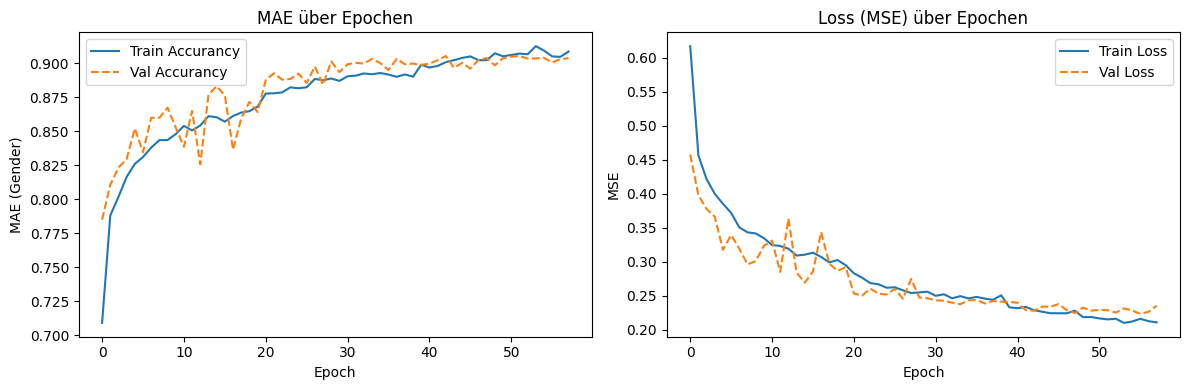

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# MAE
axes[0].plot(history.history["accuracy"],     label="Train Accurancy")
axes[0].plot(history.history["val_accuracy"], label="Val Accurancy", linestyle="--")
axes[0].set_title("MAE über Epochen")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MAE (Gender)")
axes[0].legend()

# Loss
axes[1].plot(history.history["loss"],     label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss", linestyle="--")
axes[1].set_title("Loss (MSE) über Epochen")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE")
axes[1].legend()

plt.tight_layout()
plt.savefig("../docs/gender_model/gender_model_learning_curves.png", dpi=120)
plt.show()

Accuracy: 78.10%


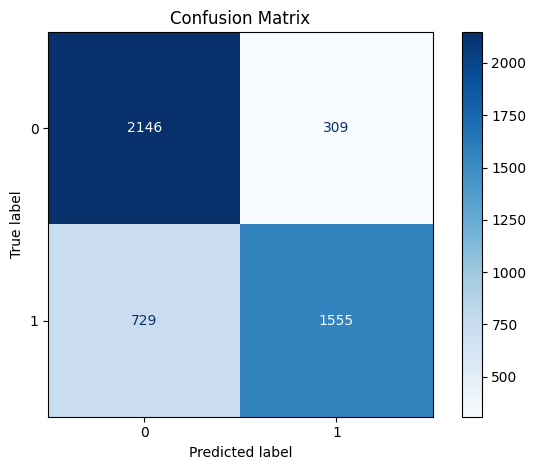

In [ ]:
from keras.models import load_model
best_model = load_model("../models/best_gender_predict_model.keras")

# Predict class probabilities and get predicted class indices
y_pred_probs = best_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Calculate accuracy
accuracy = np.mean(y_pred == y_true)
print(f"Accuracy: {accuracy:.2%}")

# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()      
plt.savefig("../docs/gender_model/gender_model_confusion_matrix.png", dpi=120)
plt.show()

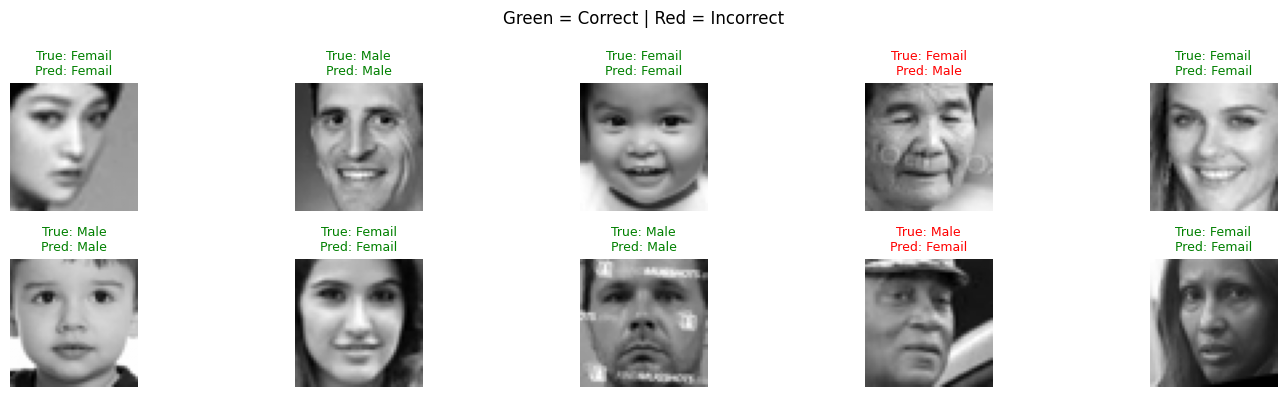

In [22]:
# Show 10 random test images with predicted and true gender labels (classification)
indices = random.sample(range(len(X_test)), 10)
sample_imgs = X_test[indices]
sample_true = np.argmax(y_test[indices], axis=1)
sample_pred_probs = best_model.predict(sample_imgs, verbose=0)
sample_pred = np.argmax(sample_pred_probs, axis=1)

race_labels = {0: "Male", 1: "Femail"}

plt.figure(figsize=(15, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow((sample_imgs[i]*255).reshape(IMG_SIZE), cmap="gray")
    true_label = race_labels.get(sample_true[i], str(sample_true[i]))
    pred_label = race_labels.get(sample_pred[i], str(sample_pred[i]))
    color = "green" if sample_pred[i] == sample_true[i] else "red"
    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=9, color=color)
    plt.axis("off")
plt.suptitle("Green = Correct | Red = Incorrect")
plt.tight_layout()
plt.show()

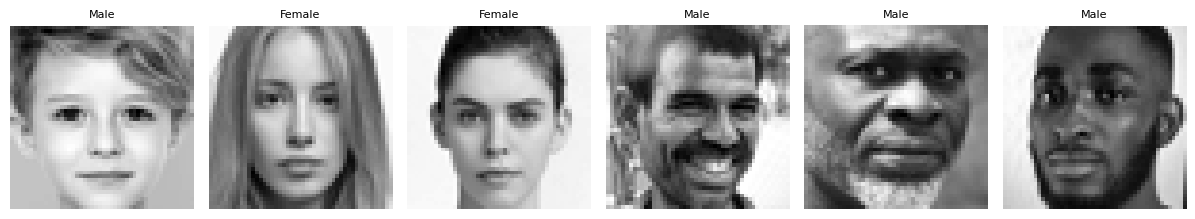

In [20]:
import os
from PIL import Image
import matplotlib.pyplot as plt

gender_labels_dict = {0: "Male", 1: "Female"}

test_dir = "../Test"
test_files = [f for f in os.listdir(test_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

plt.figure(figsize=(20, 3))
for i, file in enumerate(test_files[:10]):
    img_path = os.path.join(test_dir, file)
    img = Image.open(img_path).convert("L").resize(IMG_SIZE)
    img_array = np.array(img, dtype=np.float32) / 255.0
    img_array = img_array.reshape(1, IMG_SIZE[0], IMG_SIZE[1], 1)
    pred = best_model.predict(img_array, verbose=0)
    pred_class = int(np.argmax(pred, axis=1)[0])
    pred_label = gender_labels_dict.get(pred_class, str(pred_class))
    plt.subplot(1, 10, i+1)
    plt.imshow(img, cmap="gray")
    plt.title(f"{pred_label}", fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()